In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
from jax.config import config as jax_config
jax_config.update("jax_enable_x64", True)
jax_config.update('jax_disable_jit', False)
import objax

import legogp as lego
from legogp import settings
from legogp.trainers import SimpleTrainer, ScipyTrainer, NatGradTrainer, GradDescentTrainer
from legogp.trainers.callbacks import progress_bar_callback
from legogp.kernels import Matern32
from legogp.likelihood import Gaussian, ReshapedGaussian
from legogp.data import TemporalData, Data
from legogp.models import GP
from legogp.sparsity import NoSparsity
from legogp.transforms import Independent
from legogp.approximate_posteriors import MeanFieldApproximatePosterior , MeanFieldConjugateGaussian, ConjugateGaussian, FullConjugateGaussian


import matplotlib.pyplot as plt

import numpy as np

from data_zoo import single_output_timeseries


# Introduction


In the regression setting a variational GP can recover the standard GP in a single natural gradient step. Here we show this empirically. 

# Timeseries setting

In [3]:
# Fix randomness
np.random.seed(0)

XS, X, Y = single_output_timeseries(100, 1000, seed=0)

config = {
    'ls': 0.1,
    'lik_var': 0.1,
    'epochs': 100,
    'lr': 0.01
}

res_time = {}

## Batch GP

In [15]:
def timeseries_batch_gp(config, XS, X, Y):
    data = Data(X, Y)
    kernel = Matern32(lengthscales=[config['ls']])
    lik = Gaussian(variance=config['lik_var'])
    
    m = GP(
        data = data,
        kernel=kernel,
        likelihood=lik,
        inference='Batch'
    )
    
    learning_curve, training_time = SimpleTrainer().train(
        m, 
        objax.optimizer.Adam,
        config['lr'],
        config['epochs'],
        callback = None
    )
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['batch'] = timeseries_batch_gp(config, XS, X, Y)

/Users/ohamelijnck/Documents/projects/legogp/legogp/defaults.py:28: UserWarning: Using default Independent prior
  warnings.warn('Using default Independent prior')


## State-space GP

In [5]:
def timeseries_sde_gp(config, XS, X, Y):
    data = TemporalData(X=X, Y=Y, sort=True)
    kernel = Matern32(lengthscales=[config['ls']])
    lik = ReshapedGaussian(Gaussian(variance=config['lik_var']), num_blocks=data.Nt, block_size=data.Ns)
    
    m = GP(
        data = data,
        kernel=kernel,
        likelihood=lik,
        inference='Sequential'
    )
    
    learning_curve, training_time = SimpleTrainer().train(
        m, 
        objax.optimizer.Adam,
        config['lr'],
        config['epochs'],
        callback = None
    )
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['sde'] = timeseries_sde_gp(config, XS, X, Y)

## Variational GP

In [16]:
def vi_timeseries_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    data = Data(X, Y)
    sparsity = NoSparsity(Z_ref=data._X)
    
    kernel = Matern32(lengthscales=[config['ls']])
    prior = Independent([GP(sparsity=sparsity, kernel=kernel)])
    lik = Gaussian(variance=config['lik_var'])
    
    m = GP(
        data = data,
        prior = prior,
        likelihood = [lik],
        inference = 'Variational'
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # Do not use adam for the approx posterios
    all_vars = list(m.vars().keys())
    m_name = [a for a in all_vars if a.endswith('._m(Parameter).raw_var')]
    s_chol_name = [a for a in all_vars if a.endswith('._S_chol(Parameter).raw_var')]
    approx_posterior_vars = m_name + s_chol_name
            
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam, hold_vars = approx_posterior_vars)
    
    learning_curve = []
    for i in range(config['epochs']):
        try:
            obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
            grad_step.train(config['lr'], epochs=1)
            learning_curve.append(obj_val[0])
        except Exception as e:
            print(f'Exiting at {i}')
            break
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['vi'] = vi_timeseries_gp(config, XS, X, Y)

/Users/ohamelijnck/Documents/projects/legogp/legogp/approximate_posteriors/gaussian_approximate_posterior.py:21: UserWarning: Approximate posterior 
  warnings.warn('Approximate posterior ')


## CVI with Batch surrogate GP

In [7]:
def cvi_t_batch_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    Q = 1
    
    data = Data(X=X, Y=Y)
    sparsity = [NoSparsity(Z_ref=data._X)]
    
    kernel = Matern32(lengthscales=[config['ls']])
    latent_gps = [GP(sparsity=sparsity[0], kernel=kernel)]
    lik = Gaussian(variance=config['lik_var'])
    
    approx_posterior = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=sparsity[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=Data(X=X.raw_Z, Y=Y[..., 0]), # extra dimension to handle blocks 
                prior=Independent([latent_gps[q]]), 
                likelihood=likelihood[0],
                inference='Batch'
            )  
        )
        for q in range(Q)
    ])
    
    m = GP(
        data = data,
        prior = Independent(latent_gps),
        likelihood = [lik],
        approximate_posterior=approx_posterior,
        inference = 'Variational'
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # when using a step size of 1.0 we dont need to remove params from adam
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        grad_step.train(config['lr'], epochs=1)
        #learning_curve.append(0.0)
        learning_curve.append(obj_val[0])
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['cvi_t_batch'] = cvi_t_batch_gp(config, XS, X, Y)

## CVI with SDE surrogate GP

In [8]:
def cvi_t_sde_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    Q = 1
    
    data = Data(X=X, Y=Y)
    sparsity = [NoSparsity(Z_ref=data._X)]
    
    kernel = Matern32(lengthscales=[config['ls']])
    latent_gps = [GP(sparsity=sparsity[0], kernel=kernel)]
    lik = Gaussian(variance=config['lik_var'])
    
    approx_posterior = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=sparsity[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=TemporalData(X=X.raw_Z, Y=Y, sort=False), # Data should already be in the correct format
                prior=Independent([latent_gps[q]]), 
                likelihood=likelihood[0],
                inference='Sequential'
            )  
        )
        for q in range(Q)
    ])
    
    m = GP(
        data = data,
        prior = Independent(latent_gps),
        likelihood = [lik],
        approximate_posterior=approx_posterior,
        inference = 'Variational'
    )
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # when using a step size of 1.0 we dont need to remove params from adam
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        grad_step.train(config['lr'], epochs=1)
        #learning_curve.append(0.0)
        learning_curve.append(obj_val[0])
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['cvi_t_sde'] = cvi_t_sde_gp(config, XS, X, Y)

## Plot Learning rates

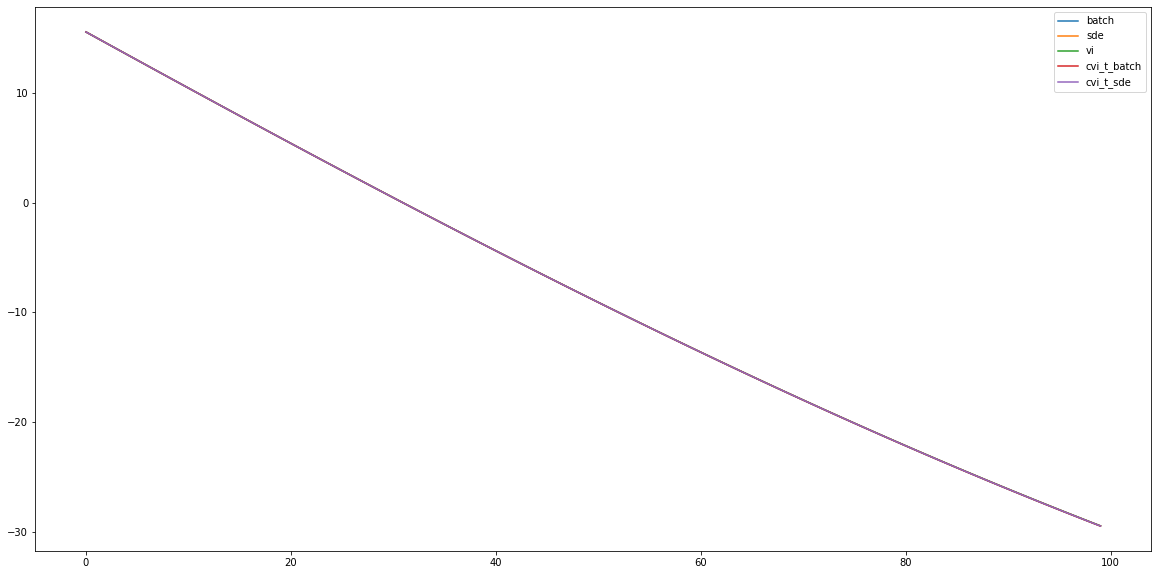

In [9]:
fig = plt.figure(figsize=(20, 10))
ax = plt.gca()
for m in res_time.keys():
    ax.plot(res_time[m]['lc'], label=m)
plt.legend()

# Predictions

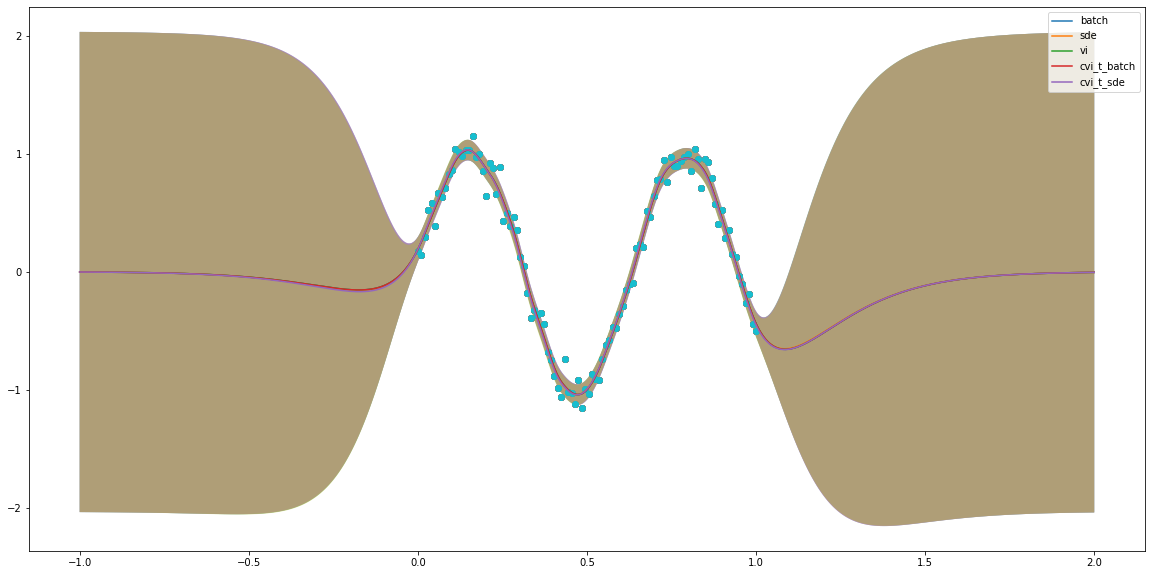

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

for m in res_time.keys():
    ax.fill_between(
        np.squeeze(XS), 
        np.squeeze(res_time[m]['pred_mu']-1.96*res_time[m]['pred_var']), 
        np.squeeze(res_time[m]['pred_mu']+1.96*res_time[m]['pred_var']),
        alpha=0.4
    )
    ax.plot(XS, res_time[m]['pred_mu'], label=m)
    ax.scatter(X, Y)
    

ax.legend()

In [11]:
res_time.keys()

dict_keys(['batch', 'sde', 'vi', 'cvi_t_batch', 'cvi_t_sde'])